In [ ]:
!git clone https://github.com/ODBapp/2025_NODASS_workshop.git
!pip install EMD-signal

In [ ]:
%cd 2025_NODASS_workshop/src/timeseries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from typing import Literal
from statsmodels.tsa.seasonal import STL
from PyEMD import EEMD
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.signal import periodogram
from timeseries_utils import *

In [3]:
# Testing EEMD by simulating a time series
# 1. Simulate trend + seasonality + noise
np.random.seed(41)
n = 600
t = np.arange(n)
time_index = pd.date_range("1970-01-01", periods=n, freq="ME")
random_ph1 = np.random.uniform(0, np.pi)
random_ph2 = np.random.uniform(0, np.pi)

mu = -2 + 0.001 * t                       # 線性趨勢 -2 + 600 * 0.001 = -1.4
ss = 0.8 * np.sin(2 * np.pi * t / 12)     # 每 12 期的季節性
mm = 0.23 * np.cos(2 * np.pi * t / 43 + random_ph1)    # mid-term seasonality
ll = 0.15 * np.sin(2 * np.pi * t / 101 + random_ph2)   # long-term seasonality
e = 0.5 * np.random.randn(n)            # 隨機噪音
y = mu + ss + mm + ll + e

df = pd.DataFrame({"y": y, "signal": mu + ss + mm + ll}, index=time_index)

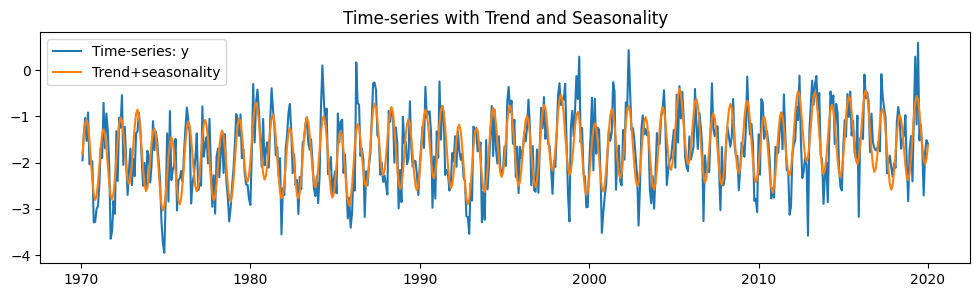

In [4]:
plt.figure(figsize=(12, 3))
plt.plot(df.index, df["y"], label="Time-series: y")
plt.plot(df.index, df["signal"], label="Trend+seasonality")
plt.legend()
plt.title("Time-series with Trend and Seasonality");

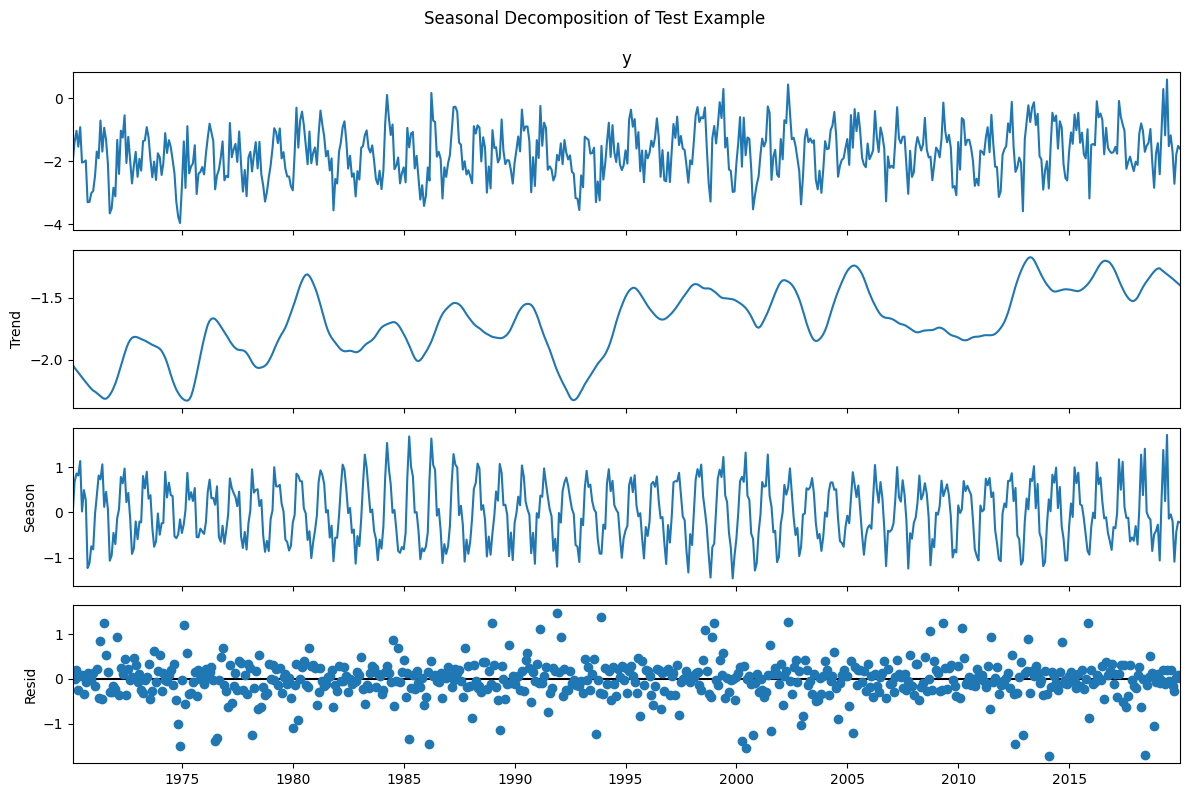

In [5]:
stl = STL(df["y"],
          period=12,
          robust=True).fit()
fig = stl.plot()
fig.set_size_inches(12, 8)
fig.suptitle(f"Seasonal Decomposition of Test Example", y=0.99)
plt.tight_layout()

In [6]:
def plot_eemd_decomposition_series(series: pd.Series, label="", max_imfs=None):
    # from PyEMD import EEMD
    # import matplotlib.pyplot as plt
    # import matplotlib.dates as mdates
    # import numpy as np

    # Interpolate any gaps
    series = series.interpolate("time").dropna()
    x = series.values
    t = np.arange(len(x))

    eemd = EEMD(trials=100, noise_width=0.2)
    eemd.eemd(x, t)
    IMFs, residual = eemd.get_imfs_and_residue()

    n_imfs = IMFs.shape[0] if max_imfs is None else min(IMFs.shape[0], max_imfs)
    fig, axes = plt.subplots(n_imfs + 1, 1, figsize=(12, 2.2*(n_imfs+1)), sharex=True)

    for i in range(n_imfs):
        axes[i].plot(series.index, IMFs[i], label=f"IMF {i+1}")
        axes[i].legend(loc="upper right")
        axes[i].grid(alpha=0.3)

    axes[-1].plot(series.index, residual, 'k', label="Residual (trend)")
    axes[-1].legend(loc="upper right")
    axes[-1].grid(alpha=0.3)

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
    # ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    fig.suptitle(f"EEMD decomposition of {label} series", fontsize=14)
    fig.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

    return series, IMFs, residual


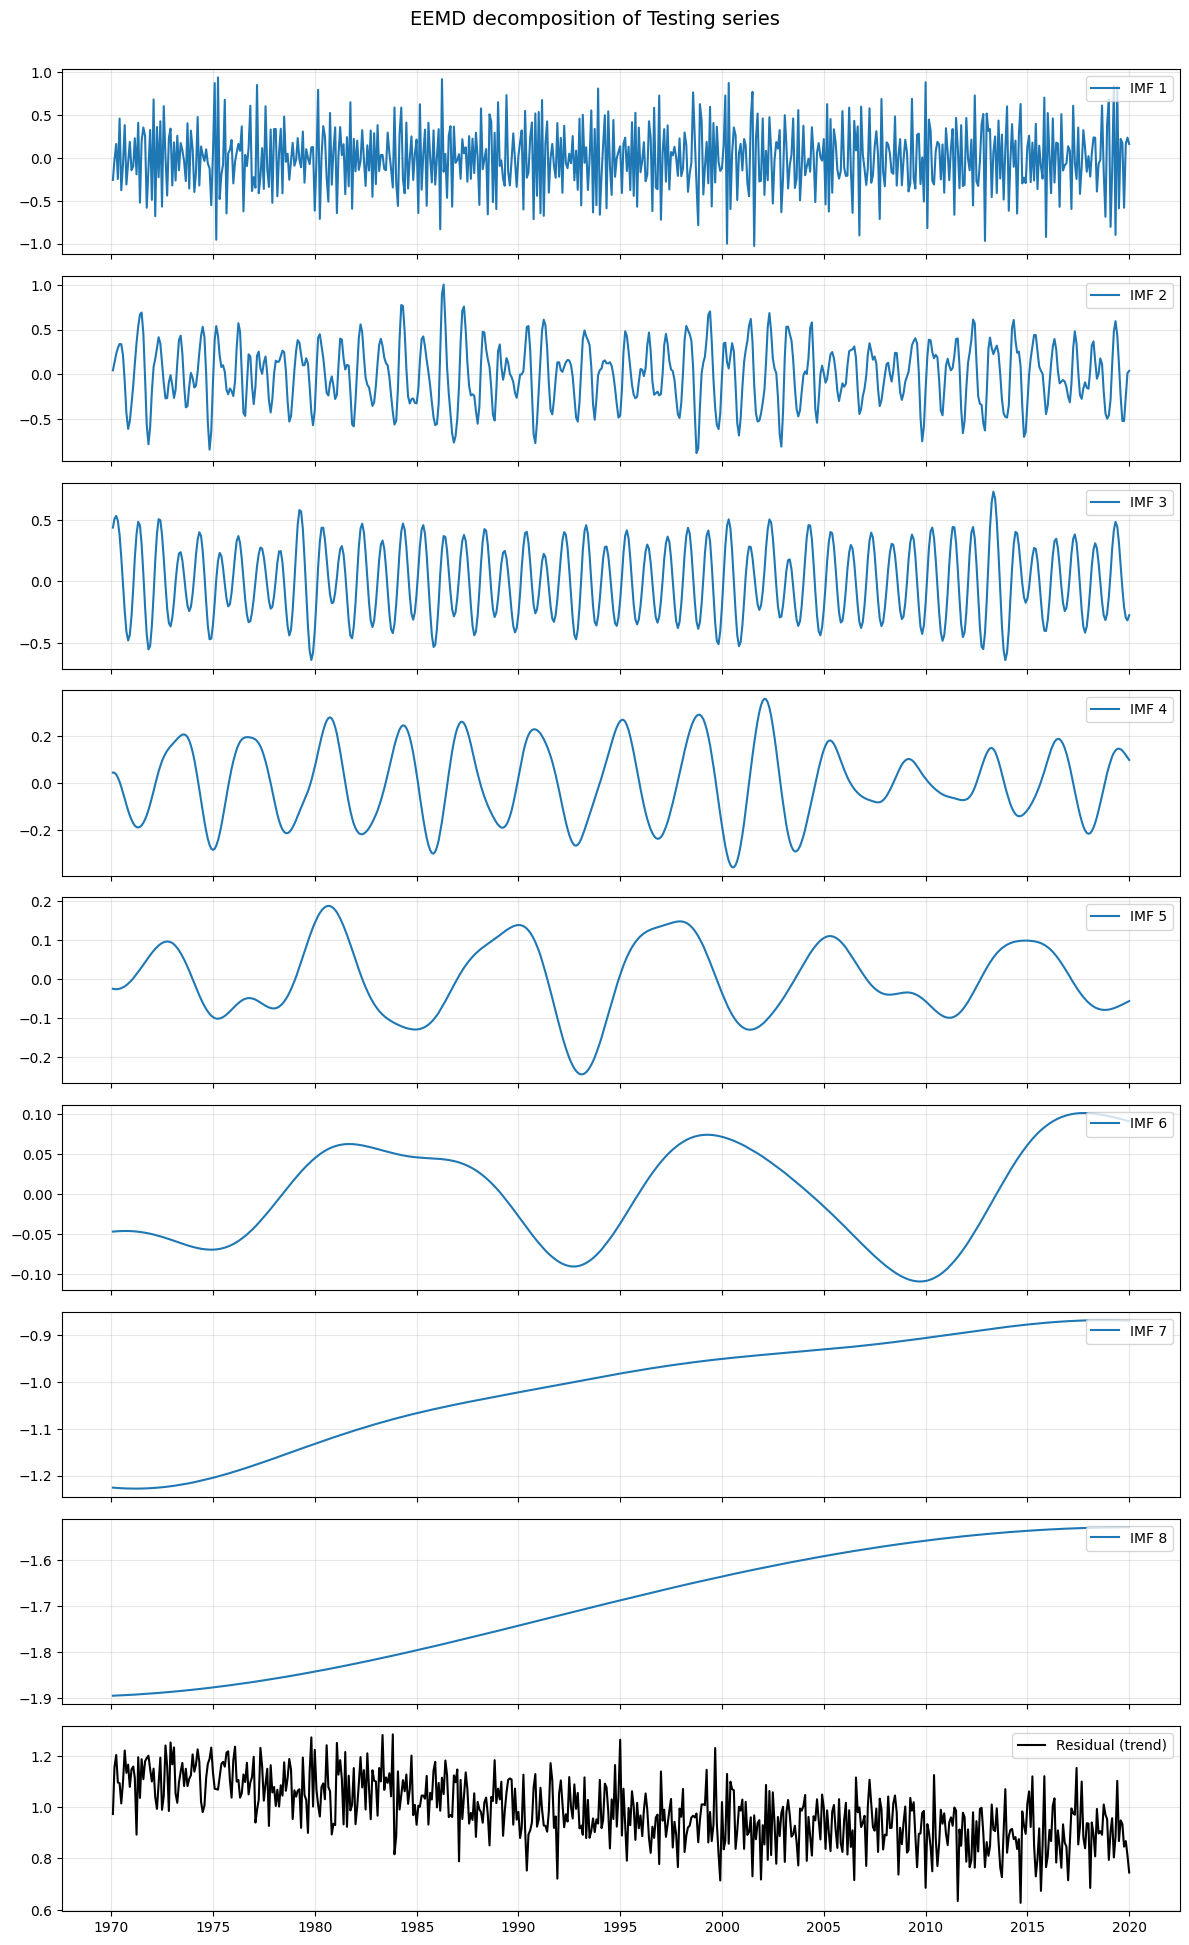

In [7]:
test_series, IMF_test, resid_test = plot_eemd_decomposition_series(df['y'], label="Testing")

In [11]:
def imf_fft_peak_periods(IMFs: np.ndarray,
                         dt: float = 1.0,
                         units: Literal["days", "months"] = "days",
                         to_months: bool = False) -> pd.DataFrame:
    """
    Compute dominant periods of IMFs using FFT.

    Args:
        IMFs: array of shape (n_imfs, n_samples)
        dt: sampling interval (1.0 = daily, 1/30 = monthly if unit is 'days')
        units: 'days' or 'months' — determines output unit

    Returns:
        DataFrame with:
            - IMF: 1-based index
            - peak_freq: cycles per unit (e.g., per day or month)
            - peak_period: inverse of peak frequency, in chosen unit
    """
    import numpy as np
    import pandas as pd

    n_imfs, N = IMFs.shape
    freqs = np.fft.rfftfreq(N, d=dt)
    result = []

    for i, imf in enumerate(IMFs, start=1):
        P = np.abs(np.fft.rfft(imf))**2
        idx = np.argmax(P[1:]) + 1  # skip DC
        f = freqs[idx]
        period = 1/f if f > 0 else np.inf
        pmonth = period/30 if to_months else np.nan
        result.append({
            "IMF": i,
            "peak_freq": f,
            f"peak_period_{units}": period
        })
        if to_months:
            result[-1]["peak_period_months"] = pmonth

    return pd.DataFrame(result)


In [14]:
fft_testing = imf_fft_peak_periods(IMF_test, dt=1.0, units="months")
print(fft_testing)

   IMF  peak_freq  peak_period_months
0    1   0.366667            2.727273
1    2   0.083333           12.000000
2    3   0.083333           12.000000
3    4   0.023333           42.857143
4    5   0.010000          100.000000
5    6   0.005000          200.000000
6    7   0.001667          600.000000
7    8   0.001667          600.000000


In [15]:
# from scipy.signal import periodogram
# Simulated IMF data (for demo, replace with your real IMF matrix)
# np.random.seed(0)
# t = np.arange(0, 3650)  # 10 years of daily data
# IMFs = [np.sin(2 * np.pi * t / p) + 0.1 * np.random.randn(len(t)) for p in [90, 120, 180, 240, 365, 512, 730, 1000]]

# Plot IMF FFTs
def plot_imf_periodograms(IMFs: np.ndarray, to_months: bool = False):
    n = len(IMFs)
    ncols = 2
    nrows = (n + 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 2.5 * nrows))
    axes = axes.ravel()

    for i, imf in enumerate(IMFs):
        f, Pxx = periodogram(imf, fs=1.0)  # fs=1 sample/day
        freq_monthly = f * (30 if to_months else 1)  # cycles/month
        ax = axes[i]
        ax.plot(freq_monthly, Pxx, color='blue', lw=1)
        ax.set_xlim(0, 0.5)
        ax.set_xlabel("Frequency (cycle/month)")
        ax.set_ylabel("Variance Density\n($m^2$/month)")

        # Estimate peak period
        peak_idx = np.argmax(Pxx[1:]) + 1  # skip DC
        peak_freq = freq_monthly[peak_idx]
        peak_period = 1 / peak_freq if peak_freq > 0 else np.nan

        if peak_freq > 0 and peak_freq < 0.5:
            ax.text(peak_freq + 0.025, Pxx.max()*0.8,  # x and y placement
                    f"Peak frequency:\n{peak_freq:.4f}",
                    fontsize=10, bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'),
                    transform=ax.transData)
        ax.set_title(f"IMF{i+1}\nPeak Period: {peak_period:.1f} months", fontsize=10)
        ax.grid(True, alpha=0.3)

    for i in range(len(IMFs), len(axes)):
        axes[i].axis("off")

    plt.tight_layout()

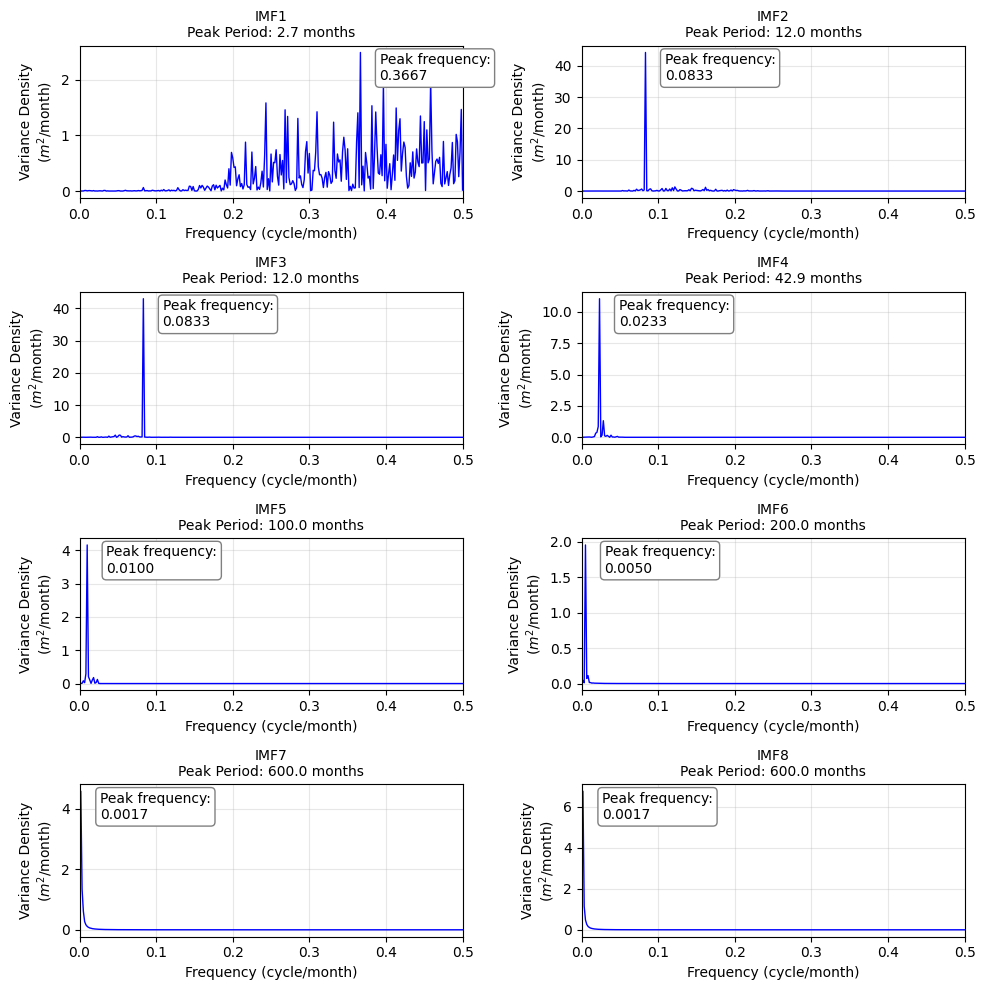

In [16]:
plot_imf_periodograms(IMF_test)

In [17]:
def extract_long_term_trend_from_eemd(imfs: np.ndarray,
                                      resid: np.ndarray,
                                      fft_stats: pd.DataFrame,
                                      add_resid: bool = True,
                                      period_fraction: float = 1/3,
                                      period_var: str = 'peak_period_months') -> tuple[list, np.ndarray]:
    """
    Extract long-term component from EEMD results by selecting IMFs whose
    peak period exceeds a fraction of the total signal length.

    Parameters
    ----------
    imfs : np.ndarray
        2D array of IMF components (n_imf, n_time).
    resid : np.ndarray
        Residual component (same length as IMF time series).
    fft_stats : pd.DataFrame
        Output from `imf_fft_peak_periods()` with 'IMF' and 'peak_period_months'.
    add_resid : bool, default=True
        Whether to include residual in final sum.
    period_fraction : float, default=1/3
        Threshold as a fraction of time length to define "long-term".

    Returns
    -------
    long_imf_indices : list
        List of IMF indices (1-based) that are considered long-term.
    long_component : np.ndarray
        1D array of the summed long-term component.
    """
    n = imfs.shape[1]
    threshold = n * period_fraction

    long_mask = fft_stats[period_var] > threshold
    long_imf_indices = fft_stats.loc[long_mask, "IMF"].values.tolist()  # 1-based index

    # Convert to 0-based index for slicing imfs
    long_imfs_array = imfs[[i - 1 for i in long_imf_indices]]

    long_component = long_imfs_array.sum(axis=0)
    if add_resid and resid is not None:
        long_component += resid

    return long_imf_indices, long_component


In [18]:
long_indices_test, long_component_test = extract_long_term_trend_from_eemd(
    imfs=IMF_test,
    resid=resid_test,
    fft_stats=fft_testing,
    add_resid=True,
    period_fraction=1/2
)

print("Long-term IMFs (1-based indices):", long_indices_test)

Long-term IMFs (1-based indices): [7, 8]


In [19]:
test_smooth = lowess(long_component_test, np.arange(IMF_test.shape[1]), frac=0.1, return_sorted=False)

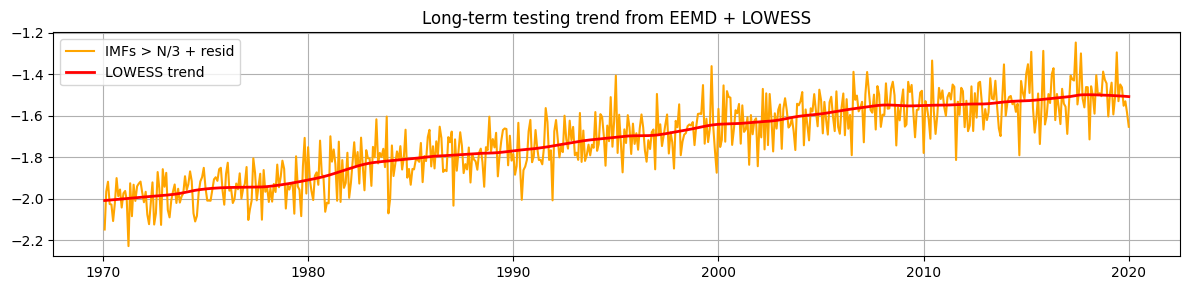

In [20]:
plt.figure(figsize=(12, 3))
plt.plot(df.index, long_component_test, label="IMFs > N/3 + resid", color="orange")
plt.plot(df.index, test_smooth, label="LOWESS trend", color="red", linewidth=2)
plt.title("Long-term testing trend from EEMD + LOWESS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
ssta = get_nino34_anomalies("1950", "2025")

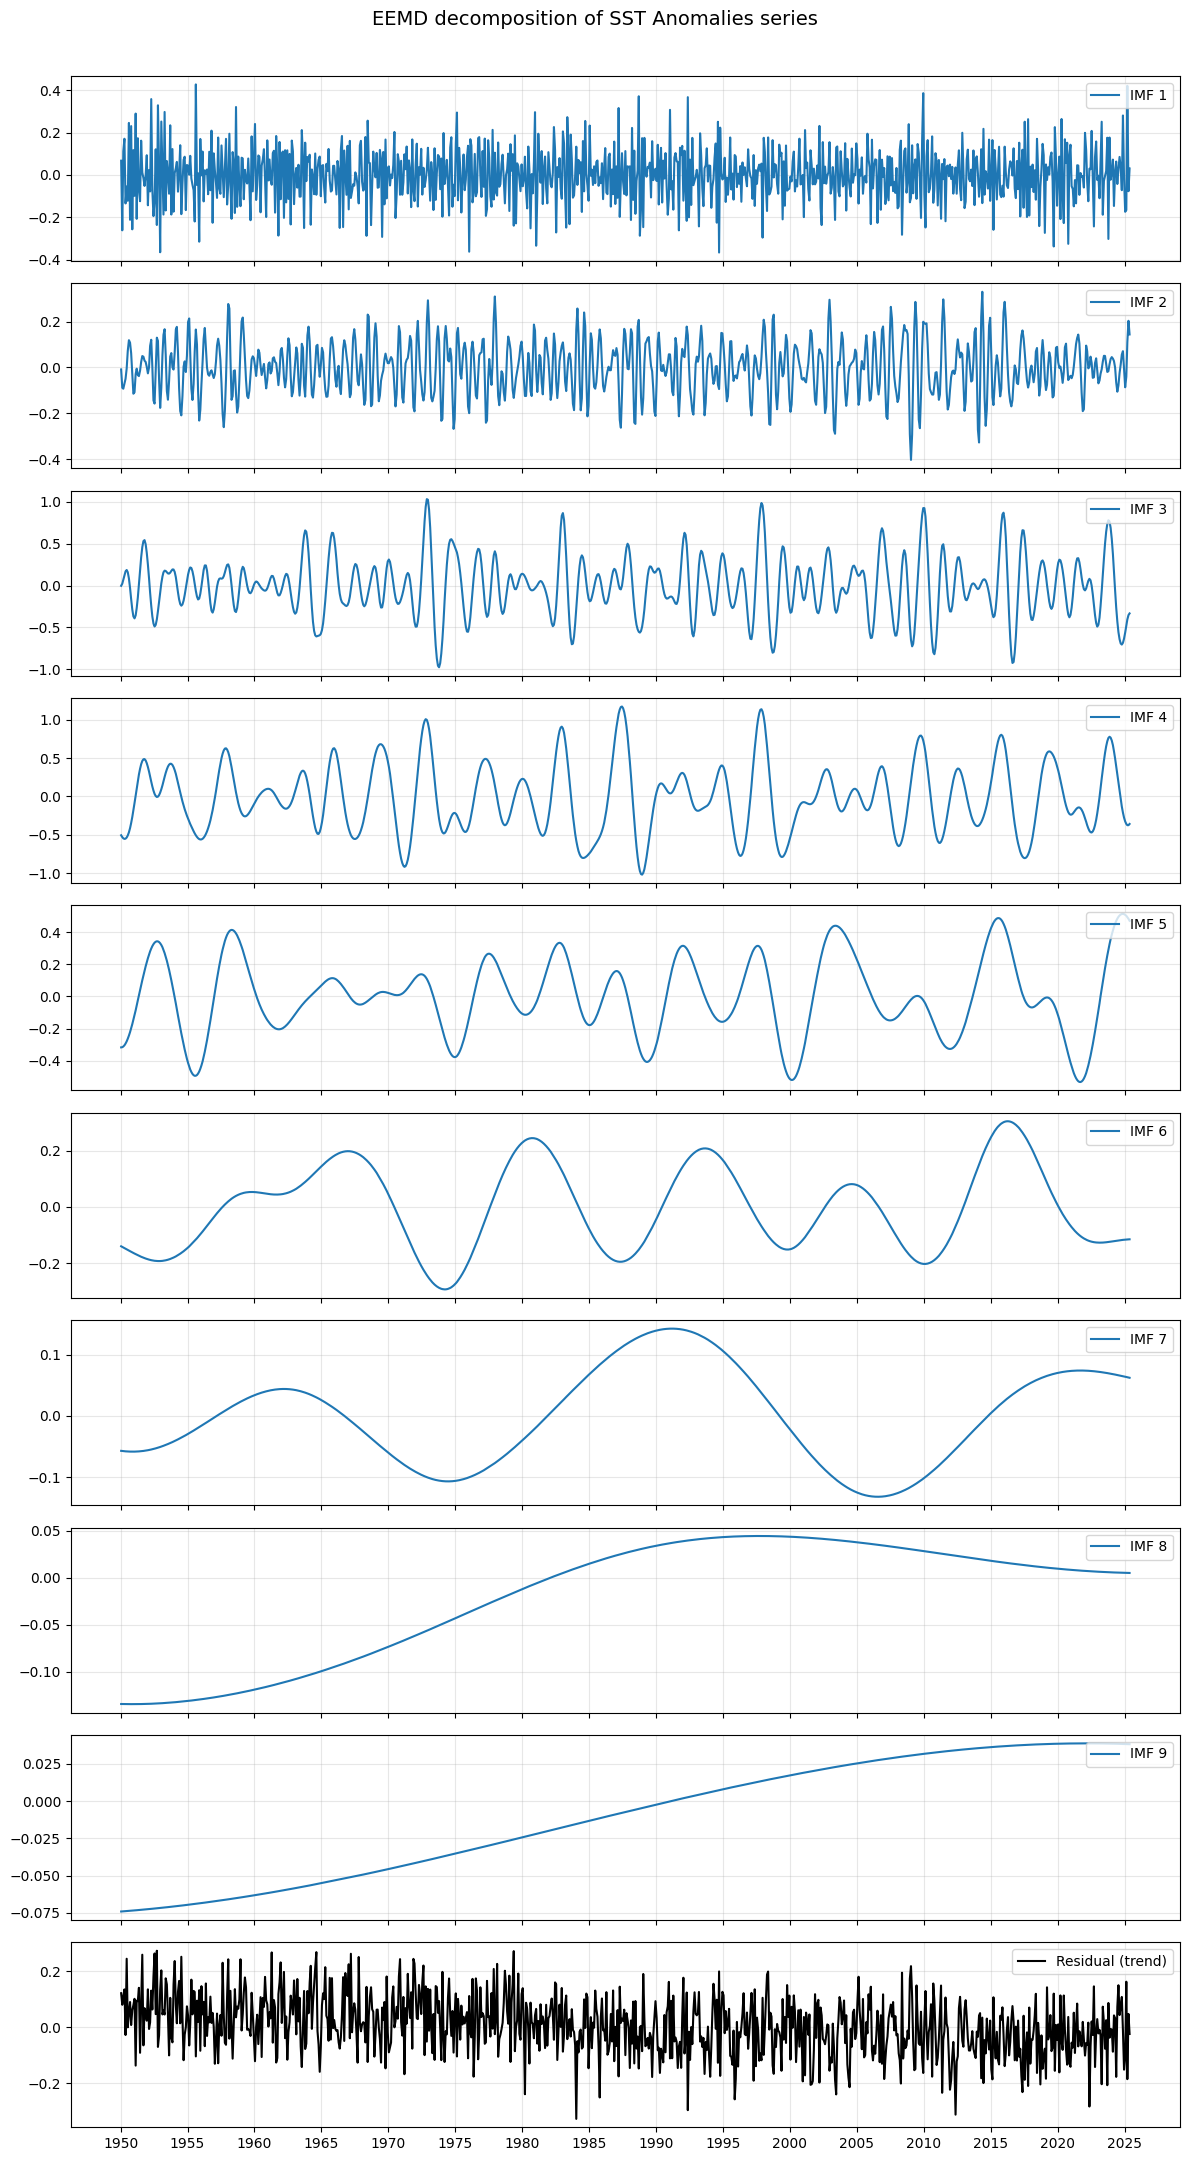

In [23]:
ssta_series, IMF_ssta, resid_ssta = plot_eemd_decomposition_series(ssta['ssta'], label="SST Anomalies")

In [24]:
fft_stats = imf_fft_peak_periods(IMF_ssta, dt=1.0, units="months")
print(fft_stats)

   IMF  peak_freq  peak_period_months
0    1   0.297238            3.364312
1    2   0.149171            6.703704
2    3   0.056354           17.745098
3    4   0.023204           43.095238
4    5   0.007735          129.285714
5    6   0.006630          150.833333
6    7   0.002210          452.500000
7    8   0.001105          905.000000
8    9   0.001105          905.000000


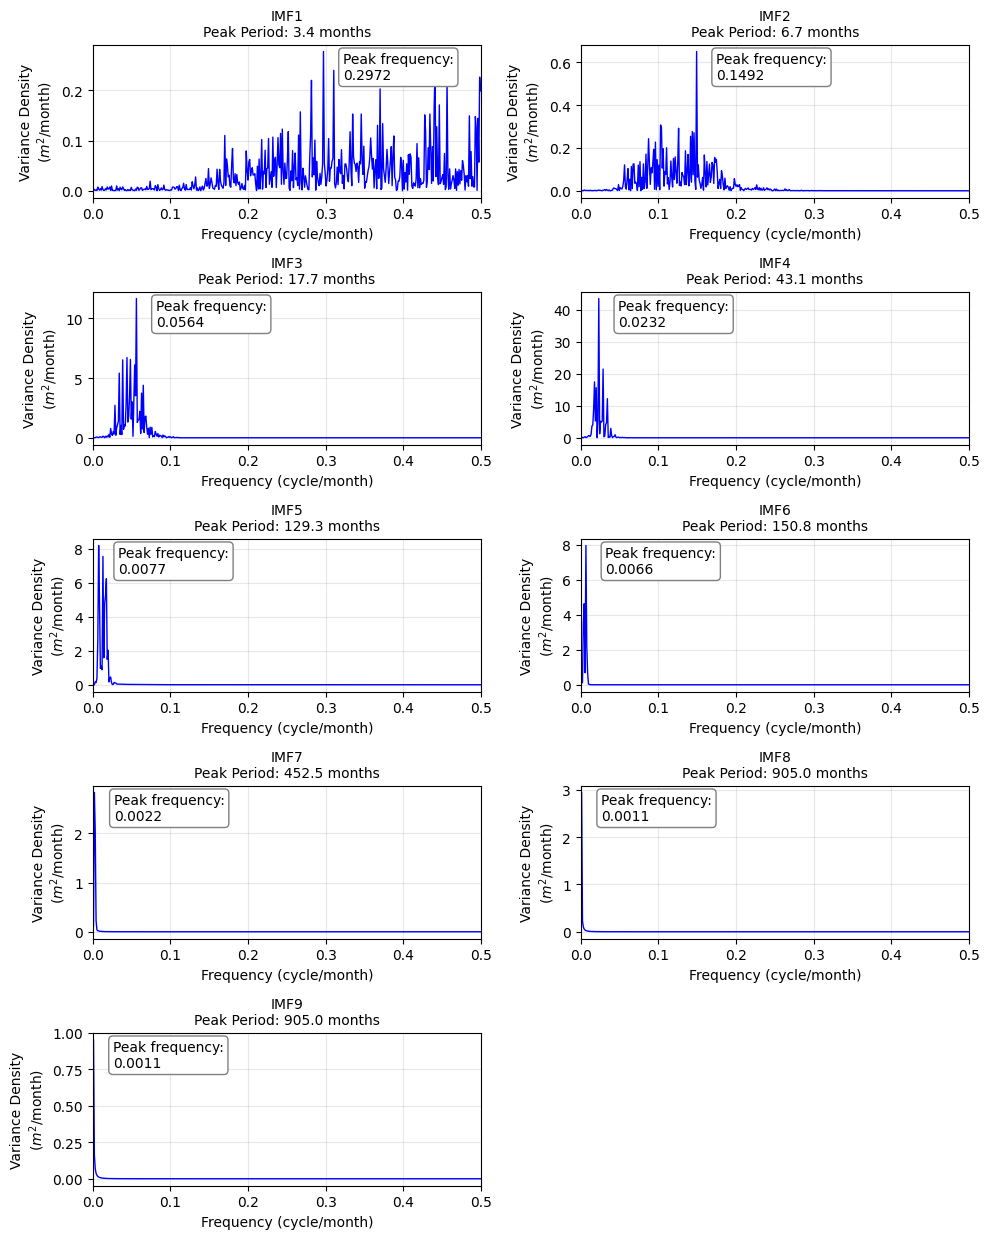

In [25]:
plot_imf_periodograms(IMF_ssta)

In [26]:
long_indices, long_component = extract_long_term_trend_from_eemd(
    imfs=IMF_ssta,
    resid=resid_ssta,
    fft_stats=fft_stats,
    add_resid=True,
    period_fraction=1/2
)

print("Long-term IMFs (1-based indices):", long_indices)

Long-term IMFs (1-based indices): [8, 9]


In [27]:
# from statsmodels.nonparametric.smoothers_lowess import lowess
# Apply LOWESS smoothing to get final trend
smooth = lowess(long_component, np.arange(IMF_ssta.shape[1]), frac=0.1, return_sorted=False)

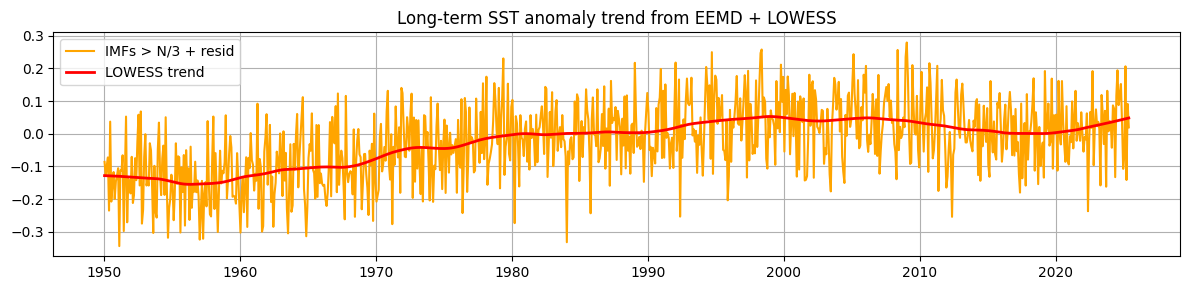

In [28]:
# Plot trend
plt.figure(figsize=(12, 3))
# plt.plot(ssta.index, ssta, label="Original SST anomaly", alpha=0.4)
plt.plot(ssta.index, long_component, label="IMFs > N/3 + resid", color="orange")
plt.plot(ssta.index, smooth, label="LOWESS trend", color="red", linewidth=2)
plt.title("Long-term SST anomaly trend from EEMD + LOWESS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [29]:
cwa_sites_df = pd.read_csv("./data/buoy/cwa_buoy_Longdong_2010-2024.csv", index_col=0, parse_dates=True)

In [30]:
VARIABLE_META = {
    "Hs": {
        "cwa_col": "示性波高",
        "label": "Significant wave height",
        "unit": "m"
    },
    "Wind": {
        "cwa_col": "風速",
        "label": "Wind speed",
        "unit": "m/s"
    },
    "SST": {
        "cwa_col": "海面溫度",
        "label": "Sea surface temperature",
        "unit": "°C"
    },
    # Add more if needed
}

# Build daily series for a specific site and variable
def build_daily_series(master, site, var="Hs"):
    s = master.loc[master["site"] == site, var]
    daily = s.resample("D").mean()
    daily = daily.interpolate("time", limit=2).dropna()
    return daily

def plot_seasonal_trend(master: pd.DataFrame, site: str, var: str = "Hs"):
    daily = build_daily_series(master, site, var)
    
    # Seasonal decomposition
    stl = STL(daily, period=365, robust=True).fit()
    meta = VARIABLE_META[var]
    fig = stl.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle(f"Seasonal Decomposition of {meta['label']} for {site} ({meta['unit']})", y=0.95)
    plt.suptitle(f"Seasonal and Trend Analysis for {site} ({var})", y=0.95)
    plt.tight_layout()
    plt.show()    

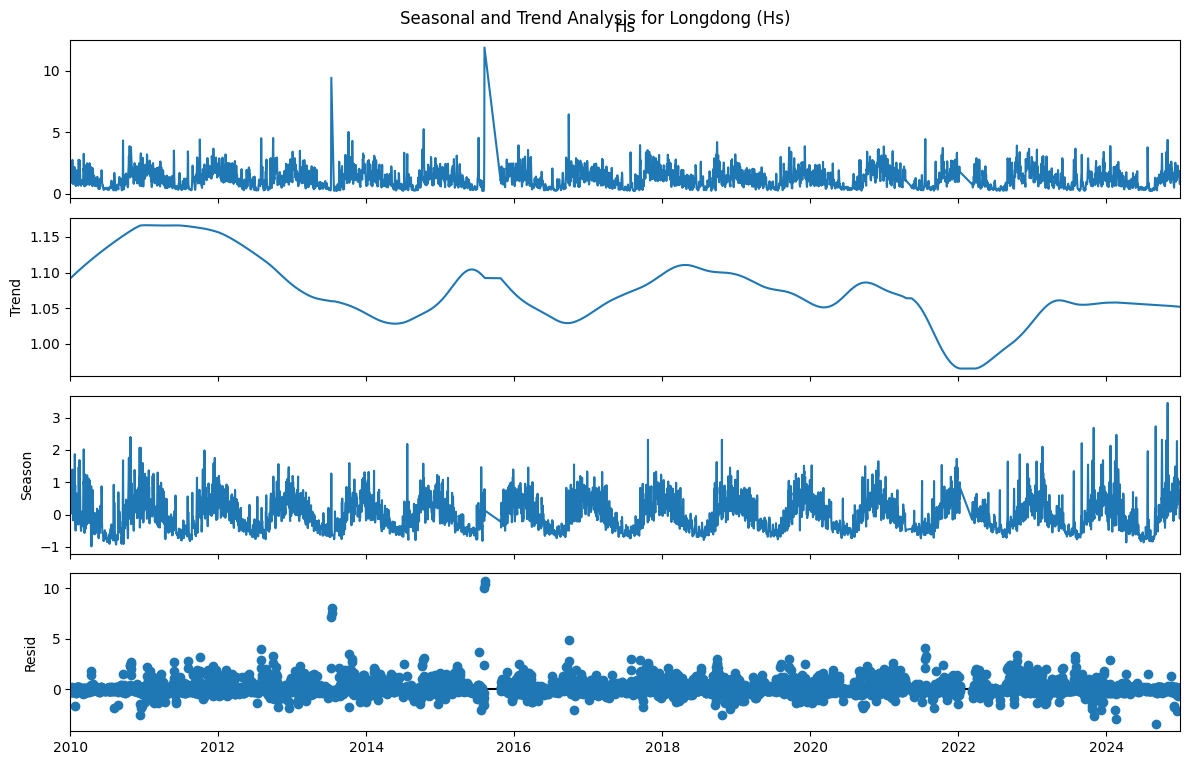

In [31]:
plot_seasonal_trend(cwa_sites_df, 'Longdong', "Hs")

In [32]:
Ld_hs = cwa_sites_df.loc[cwa_sites_df["site"] == "Longdong", "Hs"]
hs_roll = Ld_hs.rolling("72h").mean()
hs_daily = hs_roll.resample("D").mean()
hs_daily = hs_daily.interpolate("time", limit=2).dropna()

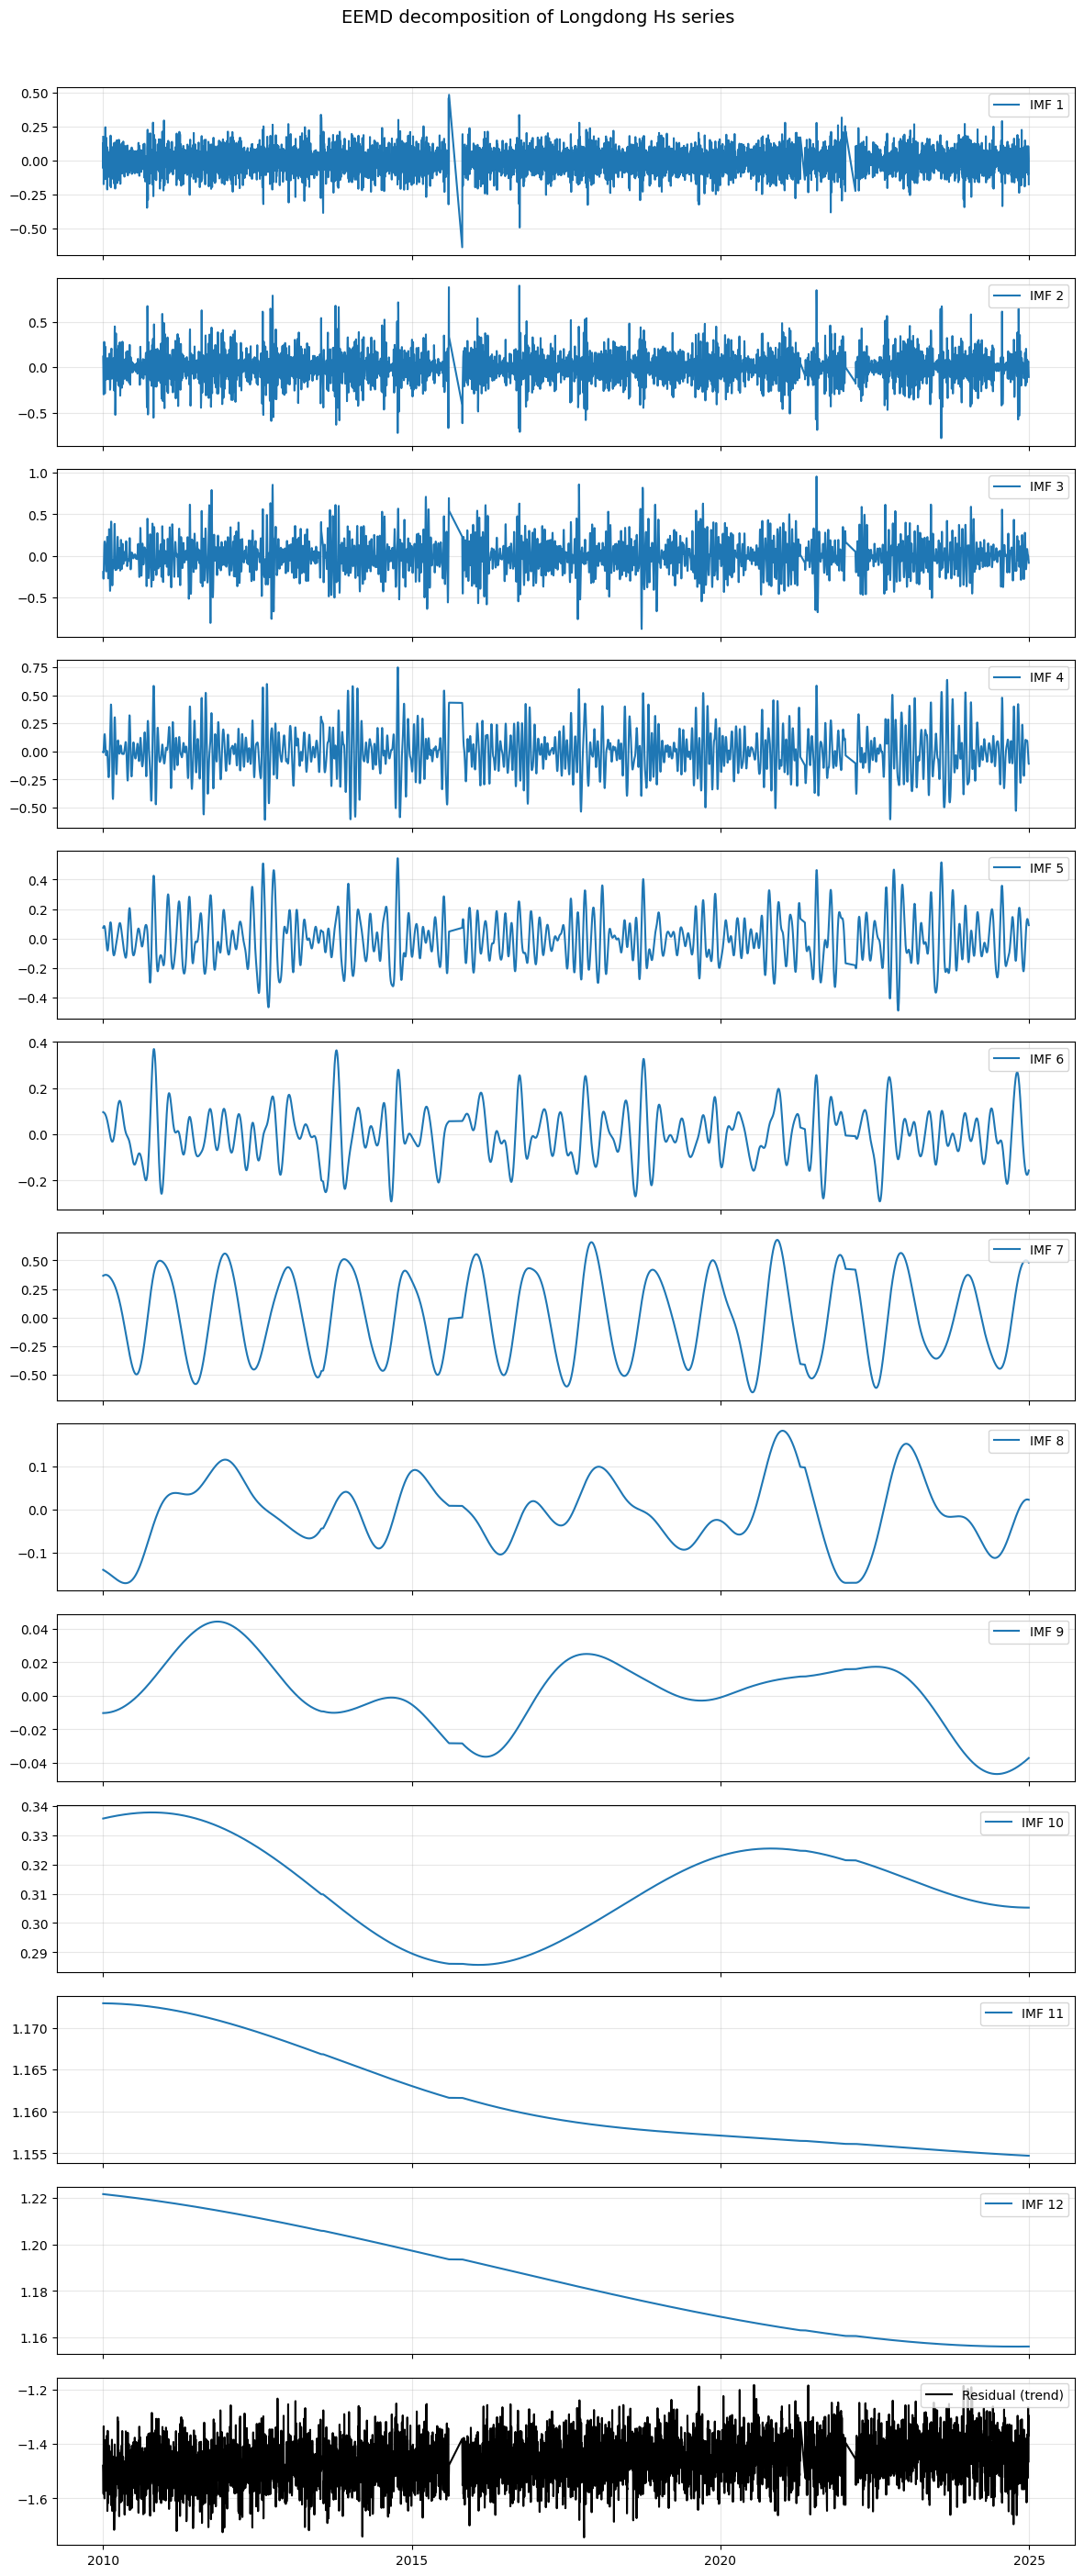

In [33]:
daily_Ld, IMF_Ld, res_Ld = plot_eemd_decomposition_series(hs_daily, 'Longdong Hs')

In [34]:
fft_stats_Ld = imf_fft_peak_periods(IMF_Ld, dt=1.0, to_months=True)
print(fft_stats_Ld)

    IMF  peak_freq  peak_period_days  peak_period_months
0     1   0.196082          5.099904            0.169997
1     2   0.131286          7.616930            0.253898
2     3   0.057826         17.293160            0.576439
3     4   0.035977         27.795812            0.926527
4     5   0.013750         72.726027            2.424201
5     6   0.008099        123.465116            4.115504
6     7   0.002825        353.933333           11.797778
7     8   0.000942       1061.800000           35.393333
8     9   0.000377       2654.500000           88.483333
9    10   0.000188       5309.000000          176.966667
10   11   0.000188       5309.000000          176.966667
11   12   0.000188       5309.000000          176.966667


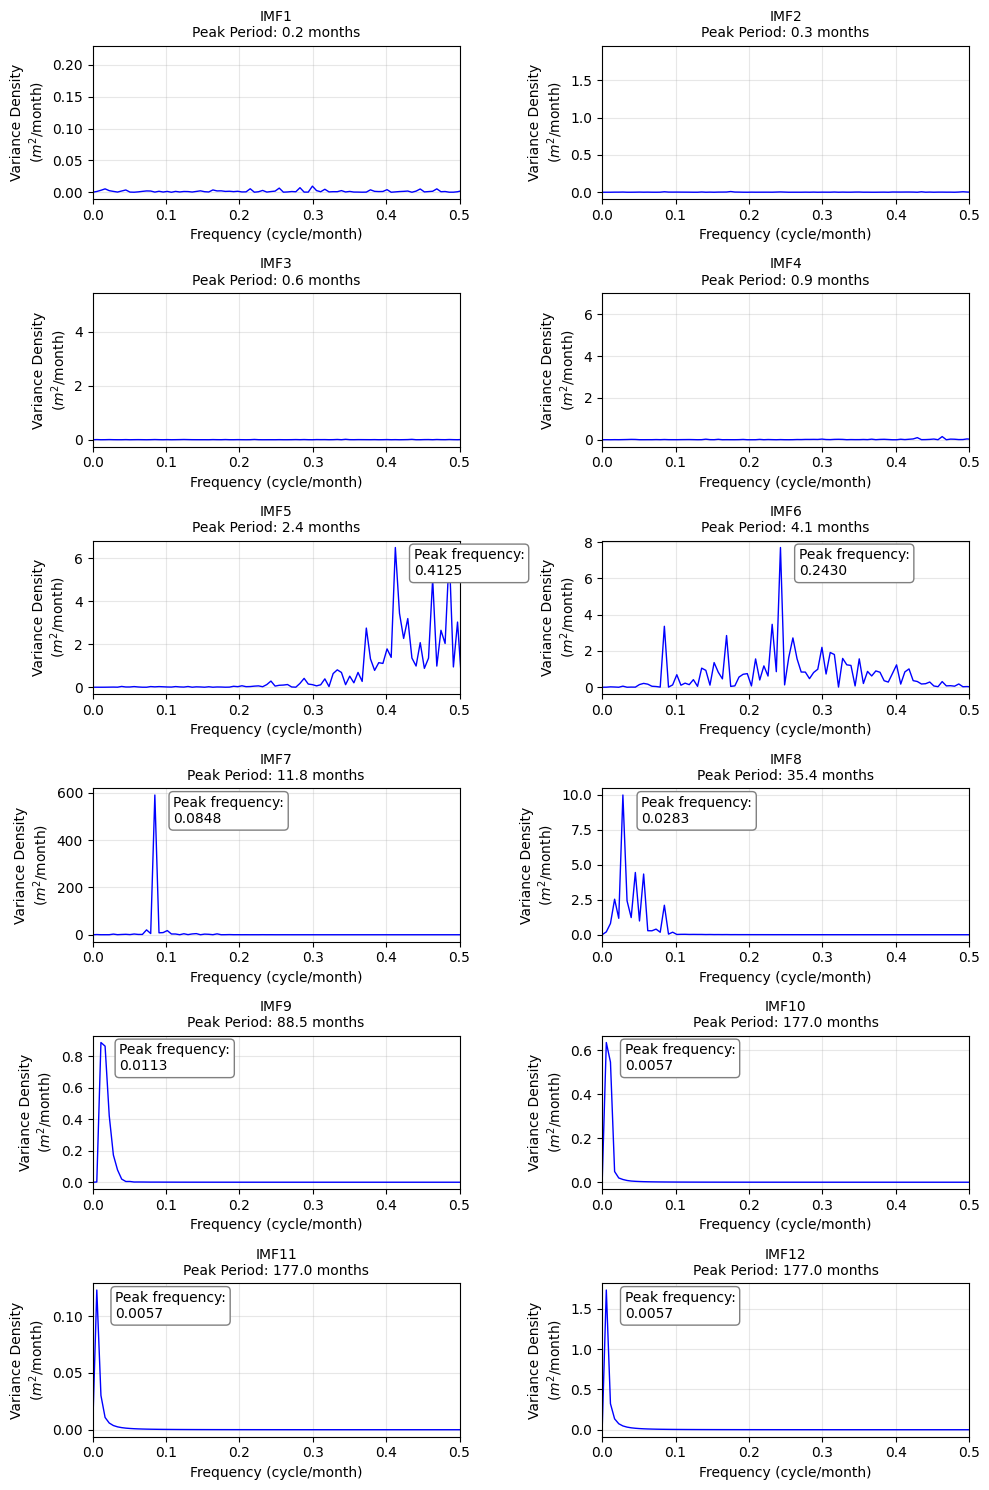

In [35]:
plot_imf_periodograms(IMF_Ld, to_months=True)

In [36]:
long_indices_Ld, long_component_Ld = extract_long_term_trend_from_eemd(
    imfs=IMF_Ld,
    resid=res_Ld,
    fft_stats=fft_stats_Ld,
    add_resid=True,
    period_fraction=1/3,
    period_var='peak_period_days'
)
print("Long-term IMFs (1-based indices):", long_indices_Ld, " Total period: ", IMF_Ld.shape[1])    


Long-term IMFs (1-based indices): [9, 10, 11, 12]  Total period:  5309


In [37]:
Ld_smooth = lowess(long_component_Ld, np.arange(IMF_Ld.shape[1]), frac=0.4, return_sorted=False)

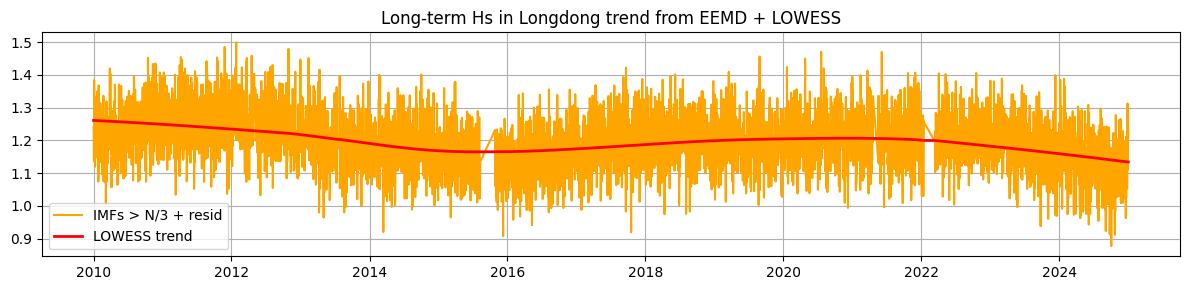

In [38]:
plt.figure(figsize=(12, 3))
plt.plot(hs_daily.index, long_component_Ld, label="IMFs > N/3 + resid", color="orange")
plt.plot(hs_daily.index, Ld_smooth, label="LOWESS trend", color="red", linewidth=2)
plt.title("Long-term Hs in Longdong trend from EEMD + LOWESS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()